# Revenue Forecast Verification — Holt-Winters
Holt-Winters Exponential Smoothing on `orders.csv`.

This notebook replicates exactly what `src/forecaster.py` does when `training_rows >= 24`:
1. Load orders.csv
2. Aggregate to monthly revenue
3. Fit Holt-Winters (additive trend + additive seasonality, 12-month period)
4. Predict next 3 months
5. Compare against the Linear Regression forecast side by side

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression

## Step 1 — Load and aggregate to monthly revenue

In [4]:
df = pd.read_csv('./data/orders.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
df.head()


C:\Users\Samyak\AppData\Local\Temp\ipykernel_32788\712289052.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'])


,order_id,user_id,product_id,order_date,quantity,total_amount
0,39,67,21,2026-04-30,5,2499.95
1,95,10,21,2026-05-15,5,2499.95
2,427,44,21,2025-11-26,5,2499.95
3,1280,9,21,2026-04-10,5,2499.95
4,1822,3,21,2025-08-07,5,2499.95


In [5]:
monthly = (
    df.groupby(df['order_date'].dt.to_period('M'))['total_amount']
    .sum()
    .reset_index()
    .rename(columns={'order_date': 'month', 'total_amount': 'revenue'})
)
monthly['month_str'] = monthly['month'].astype(str)
monthly['index']     = range(len(monthly))

print(f'Training months : {len(monthly)}')
print(f'Date range      : {monthly["month_str"].iloc[0]} → {monthly["month_str"].iloc[-1]}')
print(f'Total revenue   : ${monthly["revenue"].sum():,.2f}')
print()
monthly[['month_str', 'revenue']]

Training months : 25
Date range      : 2024-06 → 2026-06
Total revenue   : $17,614,463.37



,month_str,revenue
0,2024-06,11607.17
1,2024-07,43847.65
2,2024-08,76878.43
3,2024-09,149810.04
4,2024-10,216437.04
5,2024-11,226479.84
6,2024-12,290102.06
7,2025-01,318309.98
8,2025-02,342609.14
9,2025-03,419773.58


## Step 2 — Fit Holt-Winters

Three components:
- **Level** — current baseline value
- **Trend** — additive month-over-month growth
- **Seasonal** — additive 12-month repeating pattern

This is exactly what `_run_holt_winters()` in `src/forecaster.py` uses.

In [6]:
series = monthly['revenue'].values.astype(float)

model = ExponentialSmoothing(
    series,
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated',
)
fit = model.fit(optimized=True)

print(f'AIC (lower = better fit) : {fit.aic:.2f}')
print(f'Alpha (level smoothing)  : {fit.params["smoothing_level"]:.4f}')
print(f'Beta  (trend smoothing)  : {fit.params["smoothing_trend"]:.4f}')
print(f'Gamma (seasonal smooth.) : {fit.params["smoothing_seasonal"]:.4f}')
print()
print('Alpha near 1 = model trusts recent data heavily')
print('Alpha near 0 = model gives more weight to historical average')

AIC (lower = better fit) : 669.74
Alpha (level smoothing)  : 0.2203
Beta  (trend smoothing)  : 0.0000
Gamma (seasonal smooth.) : 0.4569

Alpha near 1 = model trusts recent data heavily
Alpha near 0 = model gives more weight to historical average


## Step 3 — Predict next 3 months
These are the values the agent should return when HoltWinters fires.

In [7]:
preds        = fit.forecast(3)
last_period  = monthly['month'].iloc[-1]
future_months = [str(last_period + i) for i in range(1, 4)]

print('=== FORECAST — Next 3 Months (Holt-Winters) ===')
print()
for month, val in zip(future_months, preds):
    print(f'  {month}   ${val:>14,.2f}')

print()
print('Compare these values against what the agent returns.')

=== FORECAST — Next 3 Months (Holt-Winters) ===

  2026-07   $  1,622,391.94
  2026-08   $  1,674,179.18
  2026-09   $  1,811,439.14

Compare these values against what the agent returns.


## Step 4 — Decompose: Level + Trend + Seasonal components

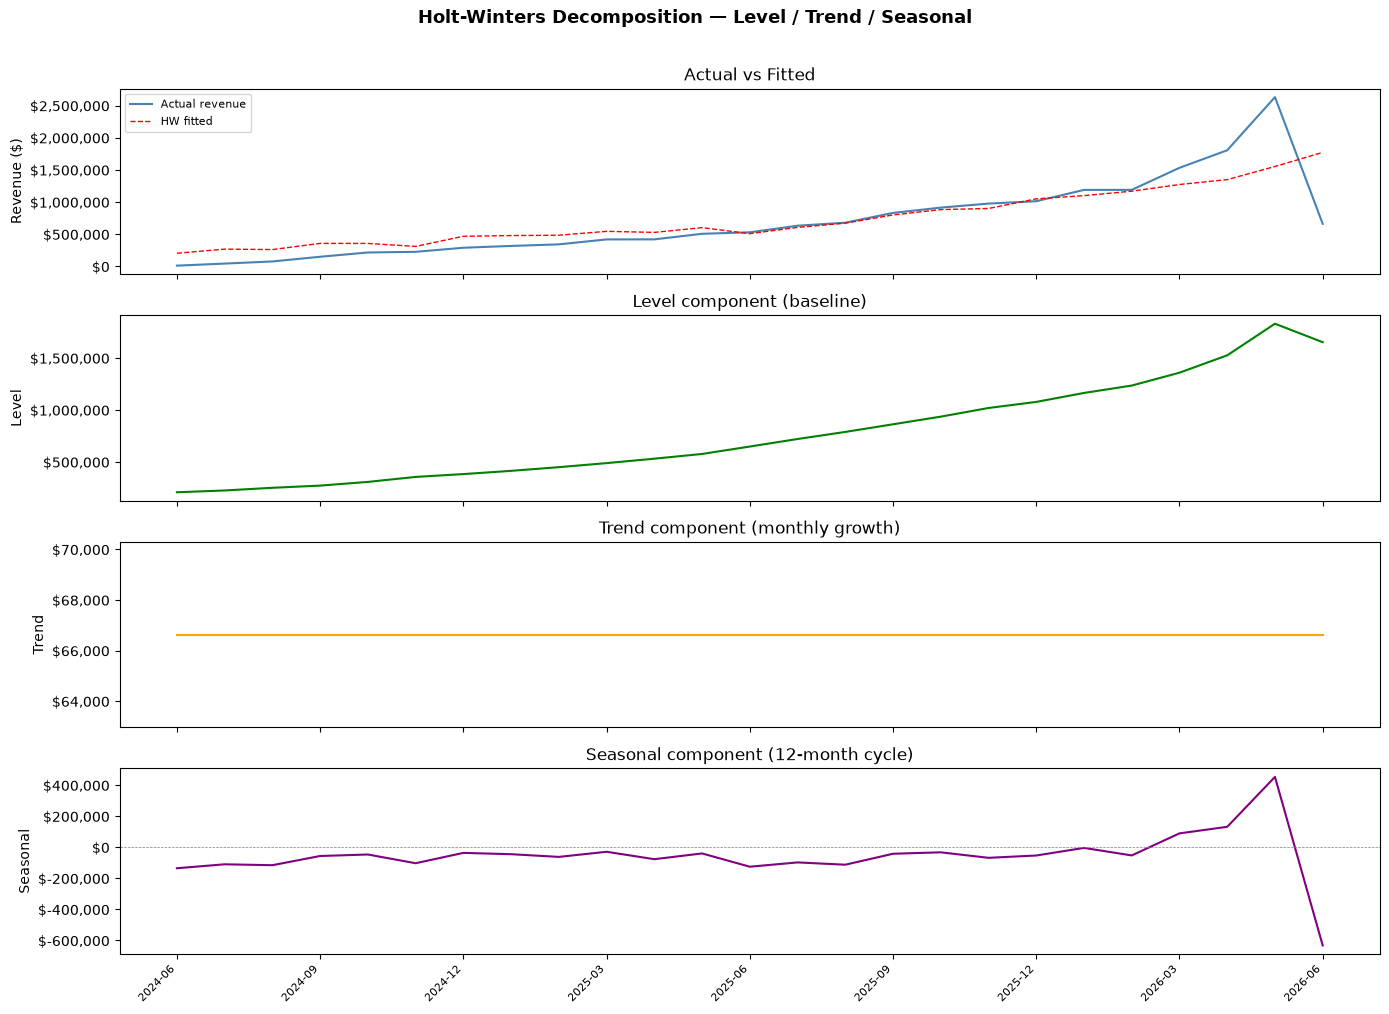

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

x = range(len(series))

# Actual
axes[0].plot(x, series, color='steelblue', linewidth=1.5, label='Actual revenue')
axes[0].plot(x, fit.fittedvalues, color='red', linewidth=1, linestyle='--', label='HW fitted')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_title('Actual vs Fitted')
axes[0].legend(fontsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

# Level
axes[1].plot(x, fit.level, color='green', linewidth=1.5)
axes[1].set_ylabel('Level')
axes[1].set_title('Level component (baseline)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

# Trend
axes[2].plot(x, fit.trend, color='orange', linewidth=1.5)
axes[2].set_ylabel('Trend')
axes[2].set_title('Trend component (monthly growth)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

# Seasonal
axes[3].plot(x, fit.season, color='purple', linewidth=1.5)
axes[3].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[3].set_ylabel('Seasonal')
axes[3].set_title('Seasonal component (12-month cycle)')
axes[3].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

# X axis labels
tick_positions = list(range(0, len(series), 3))
tick_labels    = [monthly['month_str'].iloc[i] for i in tick_positions]
axes[3].set_xticks(tick_positions)
axes[3].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)

plt.suptitle('Holt-Winters Decomposition — Level / Trend / Seasonal', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 5 — Plot historical + forecast

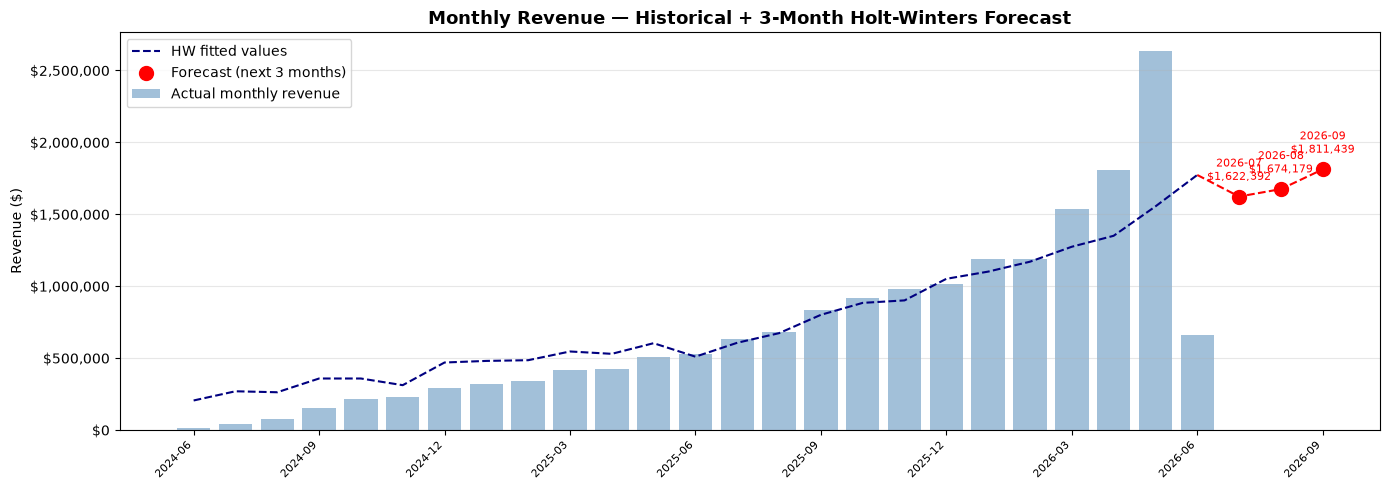

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

# Actual bars
ax.bar(monthly['index'], monthly['revenue'],
       color='steelblue', alpha=0.5, label='Actual monthly revenue')

# HW fitted line
ax.plot(monthly['index'], fit.fittedvalues,
        color='navy', linewidth=1.5, linestyle='--', label='HW fitted values')

# Forecast points
n          = len(monthly)
future_idx = [n, n+1, n+2]
ax.scatter(future_idx, preds,
           color='red', s=100, zorder=5, label='Forecast (next 3 months)')
ax.plot([n-1] + future_idx,
        [fit.fittedvalues[-1]] + list(preds),
        color='red', linewidth=1.5, linestyle='--')

# Annotate
for idx, month, val in zip(future_idx, future_months, preds):
    ax.annotate(f'{month}\n${val:,.0f}',
                xy=(idx, val), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=8, color='red')

all_labels = list(monthly['month_str']) + future_months
all_idx    = list(monthly['index'])    + future_idx
ax.set_xticks(all_idx[::3])
ax.set_xticklabels(all_labels[::3], rotation=45, ha='right', fontsize=8)

ax.set_title('Monthly Revenue — Historical + 3-Month Holt-Winters Forecast',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 — Side-by-side comparison: HoltWinters vs LinearRegression

In [10]:
# Linear regression on same data
X     = monthly[['index']].values
y     = monthly['revenue'].values
lr    = LinearRegression().fit(X, y)
lr_preds = lr.predict(np.array([[n],[n+1],[n+2]]))

print(f'{"Month":<12} {"Holt-Winters":>18} {"Linear Regression":>20} {"Difference":>15}')
print('-' * 68)
for month, hw, li in zip(future_months, preds, lr_preds):
    diff = hw - li
    print(f'{month:<12} ${hw:>16,.2f} ${li:>18,.2f} ${diff:>13,.2f}')

print()
print(f'LR  R² score : {lr.score(X, y):.4f}')
print(f'HW  AIC      : {fit.aic:.2f}  (lower AIC = better fit)')
print()
print('Note: with only 25 months and a hypergrowth trend, both models')
print('extrapolate the trend. HW adds a seasonal adjustment on top.')

Month              Holt-Winters    Linear Regression      Difference
--------------------------------------------------------------------
2026-07      $    1,622,391.94 $      1,628,087.11 $    -5,695.17
2026-08      $    1,674,179.18 $      1,699,126.23 $   -24,947.05
2026-09      $    1,811,439.14 $      1,770,165.35 $    41,273.79

LR  R² score : 0.7215
HW  AIC      : 669.74  (lower AIC = better fit)

Note: with only 25 months and a hypergrowth trend, both models
extrapolate the trend. HW adds a seasonal adjustment on top.


## Step 7 — Exclude incomplete June 2026 and reforecast

In [11]:
monthly_clean  = monthly.iloc[:-1].copy()
series_clean   = monthly_clean['revenue'].values.astype(float)
last_period_c  = monthly_clean['month'].iloc[-1]
months_clean   = [str(last_period_c + i) for i in range(1, 4)]

model_c = ExponentialSmoothing(
    series_clean,
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated',
)
fit_c   = model_c.fit(optimized=True)
preds_c = fit_c.forecast(3)

print('=== FORECAST (excluding incomplete June 2026) ===')
print()
for month, val in zip(months_clean, preds_c):
    print(f'  {month}   ${val:>14,.2f}')

print()
print('Compare with full dataset forecast above to see June 2026 impact.')

=== FORECAST (excluding incomplete June 2026) ===

  2026-06   $  3,205,508.91
  2026-07   $  3,913,383.87
  2026-08   $  4,583,327.73

Compare with full dataset forecast above to see June 2026 impact.
